# GEO Orbit Phasing

This tutorial provides a practical example on how to solve a phasing maneuver problem using Python.

## What is orbit phasing?

Orbit phasing is an orbital maneuver used to adjust the position of a spacecraft within its orbit without changing the orbit's shape or orientation. This is particularly important for satellites in geostationary orbit (GEO) that need to move along the geostationary belt to a different orbital slot, or for constellation satellites that must maintain specific relative positions within the same orbital plane.

The phasing maneuver involves temporarily changing the orbital period by adjusting the semi-major axis. By placing the satellite into a slightly different orbit (the phasing orbit), it will drift relative to its target position. After a specified number of orbits, the satellite returns to the original orbit at the desired location.

The key parameters for a phasing maneuver are:
- **Phase angle**: The angular displacement between the chaser and target satellites
- **Number of phasing orbits**: How many orbits are used to close the phase angle
- **Phasing orbit**: A temporary orbit with a different period to achieve the desired drift


The **phase angle** is the angular displacement between the two satellites at initial time. In this context, it is defined as always positive and between 0 and 360 degrees. To make the rendezvous between the satellites, it has to be reduced to 0 in a specified number of orbits (called **phasing orbits**), so each phase orbit will reduce the angular gap by just a fraction of the overall value.

$$ \theta_{gap}=\frac{\theta}{n_{orbits}}$$

where $\theta$ is the phase angle, and $\theta_{gap}$ is the angular displacement to recover after each phasing orbit.

In the code below, **Kepler's equation** is used to calculate the period and semimajor axis of the phasing orbit, given the number of revolutions around the phasing orbit itself. As first, the **eccentric anomaly E** is calculated from $\theta_{gap}$ :

$$\tan\left(\frac{E}{2}\right)=\sqrt{\frac{1 - e}{1 + e}}\tan\left(\frac{\theta_{gap}}{2}\right)$$

...and then the period of the phasing orbit is derived:

$$T_{phasing}=\frac{T_{chaser}}{2\pi}\left ( E-e \sin E \right )$$

## Problem statement

Two geostationary satellites occupy the same orbit but at different angular positions. The target satellite is at a true anomaly of 20 degrees, while the chaser satellite is at 70 degrees. Design a phasing maneuver for the chaser satellite to rendezvous with the target satellite using 5 phasing orbits over a 16-day period.

Both satellites have the following initial orbital parameters:

- Semi-major axis: 42164 km (GEO altitude)
- Eccentricity: 0.0001
- Inclination: 0.0 degrees (equatorial)
- RAAN: 0.0 degrees
- Argument of periapsis: 0.0 degrees

Compute the required $\Delta V$ for the phasing maneuvers and determine the phasing orbit parameters.

First, define the initial orbital parameters for use during calculations:

In [1]:
semimajor_axis = 42164.0
eccentricity = 0.0001
inclination = 0.0
raan = 0.0
arg_of_periapsis = 0.0

true_anomaly_target = 20.0
true_anomaly_chaser = 70.0

propagation_time = 16 * 86400
phasing_orbits = 5

## Launch a new STK instance

Start by launching a new STK instance. In this example, ``STKEngine`` is used with graphics (``no_graphics`` mode set to ``False``). This means that the STK graphic user interface (GUI) of the product is not launched but 2D and 3D visualization is still available through the STK Engine controls:

In [2]:
from ansys.stk.core.stkengine import STKEngine


stk = STKEngine.start_application(no_graphics=False)
print(f"Using {stk.version}")

Using STK Engine v13.1.0


## Create a new scenario

Start by creating a new scenario in STK:

In [3]:
root = stk.new_object_root()
root.new_scenario("PhasingOrbit")
scenario = root.current_scenario

Configure the scenario time to cover a 16 day period starting July 1, 2026:

In [4]:
start_time, stop_time = "1 Jul 2026 16:00:00.000", "+16 day"
scenario.set_time_period(start_time, stop_time)

It is now possible to show a 3D graphics window by running:

RFBOutputContext()

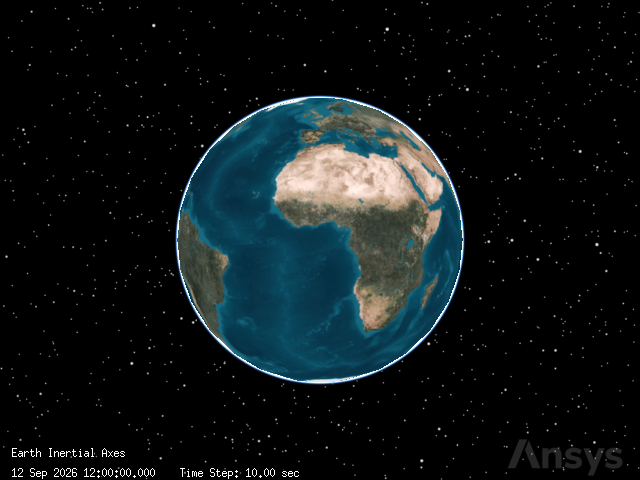

In [5]:
from ansys.stk.core.experimental.jupyterwidgets import GlobeWidget


plotter = GlobeWidget(root, 640, 480)
plotter.show()

## Add the satellites

Create the target satellite which will remain at a fixed position in geostationary orbit. This satellite serves as the reference point for the phasing maneuver:

In [6]:
from ansys.stk.core.stkobjects import STKObjectType


target_satellite = scenario.children.new(STKObjectType.SATELLITE, "Target")

Create the chaser satellite, which will need to approach the target satellite:

In [7]:
chaser_satellite = scenario.children.new(STKObjectType.SATELLITE, "Chaser")

## Set up vectors in analysis workbench

Analysis workbench (AWB) is used in this example to calculate the phase angle between the two satellites. To begin using analysis workbench, first retrieve the AWB component root:

In [8]:
awb_root = root.analysis_workbench_components_root

The phase angle component is associated with the Earth central body, so retrieve the factory that allows creating AWB components on this body:

In [9]:
earth_angle_factory = awb_root.get_provider("CentralBody/Earth").angles.factory

Create a dihedral angle component, which is a type of angle between two vectors and about a vector:

In [10]:
from ansys.stk.core.analysis_workbench import AngleType


phase_angle_awb = earth_angle_factory.create("Phase", "Phase", AngleType.DIHEDRAL_ANGLE)

Next, retrieve all of the vectors associated with the target satellite and the chaser satellite:

In [11]:
target_vectors = awb_root.get_provider(
    target_satellite.class_name + "/" + target_satellite.instance_name
).vectors
chaser_vectors = awb_root.get_provider(
    chaser_satellite.class_name + "/" + chaser_satellite.instance_name
).vectors

Retrieve the target satellite's position vector. Position vectors are automatically created on STK objects when they are added to a scenario. Then, designate this vector as the vector that the dihedral angle sweeps to:

In [12]:
target_position_vector = target_vectors.item("Position")
phase_angle_awb.to_vector.set_vector(target_position_vector)

Retrieve the chaser satellite's position vector and set it as the vector that the dihedral angle begins from:

In [13]:
chaser_position_vector = chaser_vectors.item("Position")
phase_angle_awb.from_vector.set_vector(chaser_position_vector)

Then, retrieve the target satellite's orbit normal vector, which is perpendicular to its orbit with respect to the Earth's center. Set this vector as the vector that the angle sweeps about:

In [14]:
about_vector = target_vectors.item("Orbit_Normal")
phase_angle_awb.pole_about.set_vector(about_vector)

Configure the angle to have a signed value:

In [15]:
phase_angle_awb.signed_angle = True

Finally, create a scalar calculation using the dihedral angle as input in order to record the angle values over time:

In [16]:
earth_calc_scalar_factory = awb_root.get_provider(
    "CentralBody/Earth"
).calculation_scalars.factory
phase_angle_calc = earth_calc_scalar_factory.create_angle("PhaseAngle", "PhaseAngle")
phase_angle_calc.input_angle = phase_angle_awb

## Set up the target satellite

Declare the type of orbit propagator used for the target satellite. Set the propagator to an Astrogator type:

In [17]:
from ansys.stk.core.stkobjects import PropagatorType


target_satellite.set_propagator_type(PropagatorType.ASTROGATOR)

Ensure a clean main sequence:

In [18]:
target_satellite.propagator.main_sequence.remove_all()

Then, configure graphics settings to allow 3D visualization of the satellite's trajectory:

In [19]:
target_satellite.propagator.options.draw_trajectory_in_3d = True

## Set up the initial state of the target satellite

Access the existing initial state segment in the main sequence and configure the element type to a Keplerian element:

In [20]:
from ansys.stk.core.stkobjects.astrogator import ElementSetType, SegmentType


target_initial_state = target_satellite.propagator.main_sequence.insert(
    SegmentType.INITIAL_STATE, "Initial State", "-"
)
target_initial_state.set_element_type(ElementSetType.KEPLERIAN)
target_initial_state.initial_state.epoch = scenario.start_time

Declare the Keplerian elements for the initial state using the previously defined parameters:

In [21]:
target_keplerian_elements = target_initial_state.element

target_keplerian_elements.semimajor_axis = semimajor_axis
target_keplerian_elements.eccentricity = eccentricity
target_keplerian_elements.inclination = inclination
target_keplerian_elements.raan = raan
target_keplerian_elements.true_anomaly = true_anomaly_target
target_keplerian_elements.arg_of_periapsis = arg_of_periapsis

Configure the propagation segment. Propagate the orbit of the target for 16 days:

In [22]:
target_propagate_segment = target_satellite.propagator.main_sequence.insert(
    SegmentType.PROPAGATE, "Propagate", "-"
)
target_propagate_segment.propagator_name = "Earth point mass"

target_propagate_segment.stopping_conditions[
    "Duration"
].properties.trip = propagation_time

Use the color red to identify the target satellite:

In [23]:
from ansys.stk.core.utilities.colors import Colors


target_propagate_segment.properties.color = Colors.Red

Propagate the target satellite and verify that the propagation worked correctly:

In [24]:
from ansys.stk.core.stkobjects.astrogator import RunCode


run_code = target_satellite.propagator.run_mcs()
if run_code != RunCode.MARCHING:
    raise ValueError("Could not propagate target satellite orbit.")

Finally, show the orbit of the satellite in the 3D graphics window:

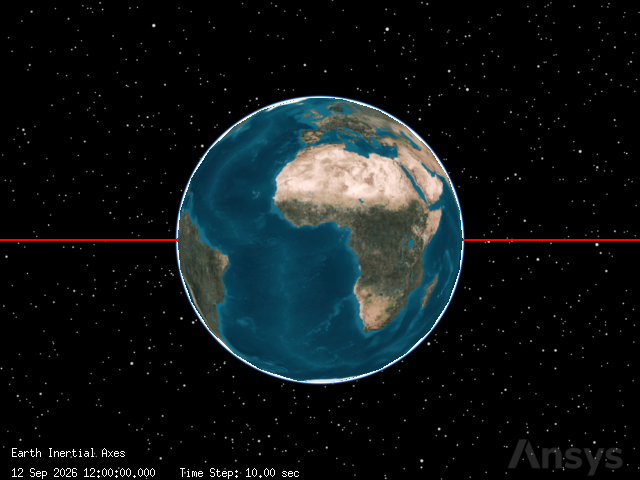

In [25]:
plotter.show()

## Set up the chaser satellite

Declare the type of orbit propagator used for the chaser satellite as the Astrogator type and ensure a clean main sequence:

In [26]:
chaser_satellite.set_propagator_type(PropagatorType.ASTROGATOR)
chaser_satellite.propagator.main_sequence.remove_all()

Configure graphics settings to allow 3D trajectory visualization:

In [27]:
chaser_satellite.propagator.options.draw_trajectory_in_3d = True

## Set up the initial state of the chaser satellite

Access the existing initial state segment in the main sequence and configure the element type to a Keplerian type:

In [28]:
chaser_initial_state = chaser_satellite.propagator.main_sequence.insert(
    SegmentType.INITIAL_STATE, "Initial State", "-"
)
chaser_initial_state.set_element_type(ElementSetType.KEPLERIAN)
chaser_initial_state.initial_state.epoch = scenario.start_time

Declare the keplerian elements using the previously defined parameters:

In [29]:
chaser_keplerian_elements = chaser_initial_state.element

chaser_keplerian_elements.semimajor_axis = semimajor_axis
chaser_keplerian_elements.eccentricity = eccentricity
chaser_keplerian_elements.inclination = inclination
chaser_keplerian_elements.raan = raan
chaser_keplerian_elements.true_anomaly = true_anomaly_chaser
chaser_keplerian_elements.arg_of_periapsis = arg_of_periapsis

Configure the propagation segment to propagate the orbit of the chaser until it reaches periapsis. This provides a well-defined, repeatable starting point in the orbit from which the phasing maneuver is applied:

In [30]:
chaser_propagate_segment = chaser_satellite.propagator.main_sequence.insert(
    SegmentType.PROPAGATE, "Propagate", "-"
)
chaser_propagate_segment.propagator_name = "Earth point mass"
chaser_propagate_segment.stopping_conditions.add("Periapsis")
chaser_propagate_segment.stopping_conditions.remove("Duration")

Run the mission control sequence of the chaser and verify that the propagation was successful:

In [31]:
run_code = chaser_satellite.propagator.run_mcs()
if run_code != RunCode.MARCHING:
    raise ValueError("Could not propagate chaser satellite orbit.")

Finally, show the orbit of the satellite using the 3D graphics window:

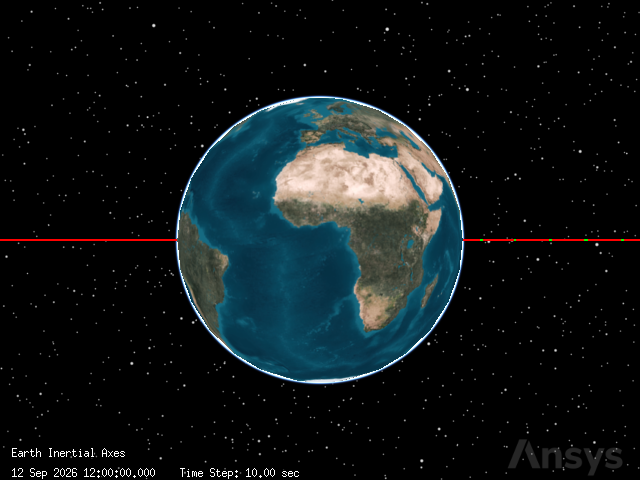

In [32]:
plotter.show()

## Calculate phasing parameters

Now, calculate the parameters for the phasing maneuver using Kepler's equation and orbital mechanics principles.

First, retrieve the mean period and semi-major axis (SMA) of the chaser satellite's initial orbit. To do so, use the Kozai-Izsak Mean data provider associated with the satellite. Use an ICRF (International Celestial Reference Frame) coordinate system:

In [33]:
mean_keplerian_data_provider = chaser_satellite.data_providers[
    "Kozai-Izsak Mean"
].group["ICRF"]

Compute the data every 60 seconds over the scenario, then convert the result to a Pandas dataframe:

In [34]:
mean_keplerian_result = mean_keplerian_data_provider.execute(
    scenario.start_time, scenario.start_time, 60
)
mean_keplerian_dataframe = mean_keplerian_result.data_sets.to_pandas_dataframe()

Finally, retrieve the initial mean period and SMA:

In [35]:
mean_orbital_period = float(mean_keplerian_dataframe.at[0, "mean nodal period"])
mean_semi_major_axis = float(mean_keplerian_dataframe.at[0, "mean semi-major axis"])

Next, calculate the phase angle, which is defined as the difference between the target and chaser orbit anomalies:

In [36]:
import math


phase_angle = math.radians(true_anomaly_target - true_anomaly_chaser)

if phase_angle < 0:
    phase_angle = 2 * math.pi + phase_angle

print(f"The initial phase angle is {math.degrees(phase_angle):.1f} deg.")

The initial phase angle is 310.0 deg.


Then, calculate the phase angle per phasing orbit:

In [37]:
phase_angle_per_orbit = phase_angle / phasing_orbits

Calculate the eccentric anomaly from the phase angle:

In [38]:
eccentric_anomaly = 2 * math.atan(
    math.sqrt((1 - eccentricity) / (1 + eccentricity))
    * math.tan(phase_angle_per_orbit / 2)
)

Use Kepler's equation to calculate the time needed to cover the phase angle in the original orbit:

In [39]:
time_to_cover_phase_angle = (mean_orbital_period / (2 * math.pi)) * (
    eccentric_anomaly - eccentricity * math.sin(eccentric_anomaly)
)

Calculate the period of the phasing orbit:

In [40]:
phasing_orbit_period = mean_orbital_period - time_to_cover_phase_angle

Then, calculate the SMA of the phasing orbit using the Earth's gravitational parameter, which is approximately 398600.44 $km^3 s^{-2} $:

In [41]:
earth_gravitational_parameter = 398600.44
transfer_semi_major_axis = math.pow(
    (phasing_orbit_period * math.sqrt(earth_gravitational_parameter)) / (2 * math.pi),
    2 / 3,
)

Next, calculate the eccentricity and the radii of the initial orbit. Start by using the chaser satellite's Astrogator data provider to retrieve the Keplerian elements of the orbit. Retrieve this data during the entire scenario at 60 second intervals and convert the data to a Pandas dataframe:

In [42]:
keplerian_elements_data_provider = chaser_satellite.data_providers[
    "Astrogator Values"
].group["Keplerian Elems"]
keplerian_result = keplerian_elements_data_provider.execute(
    scenario.start_time, scenario.start_time, 60
)
keplerian_dataframe = keplerian_result.data_sets.to_pandas_dataframe()

Retrieve the initial radius of periapsis from the dataframe then use it to determine the periapsis and apoapsis radii:

In [43]:
initial_radius = float(keplerian_dataframe.at[0, "radius_of_periapsis"])
if transfer_semi_major_axis > semimajor_axis:
    periapsis_radius = initial_radius
    apoapsis_radius = 2 * transfer_semi_major_axis - periapsis_radius
else:
    apoapsis_radius = initial_radius
    periapsis_radius = 2 * transfer_semi_major_axis - apoapsis_radius

Then, calculate the velocity of the satellite at the initial periapsis:

In [44]:
velocity_periapsis_initial = math.sqrt(
    earth_gravitational_parameter * ((2 / initial_radius) - (1 / mean_semi_major_axis))
)

Calculate the estimated desired velocity of the satellite at periapsis after phasing:

In [45]:
velocity_periapsis_final = math.sqrt(
    earth_gravitational_parameter
    * ((2 / initial_radius) - (1 / transfer_semi_major_axis))
)

Finally, estimate the velocity change (Delta-V) needed for phasing:

In [46]:
delta_v_estimate = velocity_periapsis_final - velocity_periapsis_initial

## Set up the phasing maneuver sequence

Add a target sequence to perform the first Delta-V maneuver and propagate through the phasing orbits. Add the first target sequence segment and configure it to use the active profiles:

In [47]:
from ansys.stk.core.stkobjects.astrogator import TargetSequenceAction


phasing_start_sequence = chaser_satellite.propagator.main_sequence.insert(
    SegmentType.TARGET_SEQUENCE, "Start Phasing", "-"
)
phasing_start_sequence.action = TargetSequenceAction.RUN_ACTIVE_PROFILES

Next, add an impulsive maneuver segment, through which Astrogator calculates the new state of the satellite by adding a Delta-V vector to the final state velocity of the previous segment. Configure the maneuver to use a Cartesian X control parameter:

In [48]:
from ansys.stk.core.stkobjects.astrogator import ControlManeuver, ManeuverType


first_delta_v_maneuver = phasing_start_sequence.segments.insert(
    SegmentType.MANEUVER, "DV1", "-"
)
first_delta_v_maneuver.set_maneuver_type(ManeuverType.IMPULSIVE)
first_delta_v_maneuver.enable_control_parameter(ControlManeuver.IMPULSIVE_CARTESIAN_X)

Configure the maneuver attitude to use a thrust vector with an x component 1000 times the estimated Delta-V:

In [49]:
from ansys.stk.core.stkobjects.astrogator import AttitudeControl


first_delta_v_maneuver.maneuver.set_attitude_control_type(AttitudeControl.THRUST_VECTOR)
thrust_vector = first_delta_v_maneuver.maneuver.attitude_control
thrust_vector.thrust_axes_name = "Satellite/Chaser VNC(Earth)"
thrust_vector.x = delta_v_estimate * 1000

Finally, add a propagate segment using an Earth Point Mass propagator:

In [50]:
phasing_orbit_propagate = phasing_start_sequence.segments.insert(
    SegmentType.PROPAGATE, "Phasing Orbit", "-"
)
phasing_orbit_propagate.propagator_name = "Earth point mass"

Configure the segment to display in orange:

In [51]:
phasing_orbit_propagate.properties.color = Colors.Orange

Configure the stopping conditions of the segment to use either apoapsis or periapsis based on the difference in SMAs between the orbits:

In [52]:
if transfer_semi_major_axis > semimajor_axis:
    phasing_orbit_propagate.stopping_conditions.add("Periapsis")
else:
    phasing_orbit_propagate.stopping_conditions.add("Apoapsis")

Remove the default stopping condition of the segment:

In [53]:
phasing_orbit_propagate.stopping_conditions.remove("Duration")

Then, designate that the stopping condition must be satisfied for each phasing orbit before the overall condition is met:

In [54]:
phasing_orbit_propagate.stopping_conditions.item(
    0
).properties.repeat_count = phasing_orbits

Finally, designate that the stopping condition should be calculated for the angle between the chaser's position vector and the target's position vector:

In [55]:
phasing_orbit_propagate.results.add("Vector/Angle Between Vectors")
phasing_orbit_propagate.results[0].vector1_name = "Satellite/Chaser Position"
phasing_orbit_propagate.results[0].vector2_name = "Satellite/Target Position"

## Configure the differential corrector for phasing

Set up the differential corrector to adjust the first Delta-V to achieve zero phase angle at the end of the phasing orbits:

In [56]:
from ansys.stk.core.stkobjects.astrogator import ProfileMode


phasing_differential_corrector = phasing_start_sequence.profiles[
    "Differential Corrector"
]
phasing_differential_corrector.mode = ProfileMode.ITERATE
phasing_differential_corrector.max_iterations = 50

Then, set the control parameter:

In [57]:
phasing_x_control_parameter = (
    phasing_differential_corrector.control_parameters.get_control_by_paths(
        "DV1", "ImpulsiveMnvr.Cartesian.X"
    )
)
phasing_x_control_parameter.enable = True
phasing_x_control_parameter.max_step = 0.001

Finally, configure the result of the corrector:

In [58]:
phasing_angle_result = phasing_differential_corrector.results.get_result_by_paths(
    "Phasing Orbit", "Angle_Between_Vectors"
)
phasing_angle_result.enable = True
phasing_angle_result.desired_value = 0.0
phasing_angle_result.tolerance = 0.1

## Set up the circularization maneuver

Add a second target sequence to perform the circularization Delta-V to return to the original circular orbit.

First, add a second target sequence segment to the chaser satellite's main sequence and configure it to use the active profiles:

In [59]:
circularization_sequence = chaser_satellite.propagator.main_sequence.insert(
    SegmentType.TARGET_SEQUENCE, "Circularization", "-"
)
circularization_sequence.action = TargetSequenceAction.RUN_ACTIVE_PROFILES

Next, add a maneuver segment and configure it to use an impulsive control maneuver:

In [60]:
second_delta_v_maneuver = circularization_sequence.segments.insert(
    SegmentType.MANEUVER, "DV2", "-"
)
second_delta_v_maneuver.set_maneuver_type(ManeuverType.IMPULSIVE)
second_delta_v_maneuver.enable_control_parameter(ControlManeuver.IMPULSIVE_CARTESIAN_X)

Finally, add a propagate segment to move the satellite to the final orbit. Configure it to use an Earth Point Mass propagator and stop after a duration of one day:

In [61]:
final_orbit_propagate = circularization_sequence.segments.insert(
    SegmentType.PROPAGATE, "Final Orbit", "-"
)
final_orbit_propagate.propagator_name = "Earth point mass"
final_orbit_propagate.stopping_conditions["Duration"].properties.trip = 86400

Record the eccentricity of the orbit during the segment as a result:

In [62]:
final_orbit_propagate.results.add("Keplerian Elems/Eccentricity")

Set the segment to display in yellow:

In [63]:
final_orbit_propagate.properties.color = Colors.Yellow

## Configure the differential corrector for circularization

Set up the differential corrector to achieve a circular orbit with the desired eccentricity:

In [64]:
circularization_differential_corrector = circularization_sequence.profiles[
    "Differential Corrector"
]
circularization_differential_corrector.mode = ProfileMode.ITERATE
circularization_differential_corrector.max_iterations = 50

Configure the corrector's control parameter:

In [65]:
circularization_x_control_parameter = (
    circularization_differential_corrector.control_parameters.get_control_by_paths(
        "DV2", "ImpulsiveMnvr.Cartesian.X"
    )
)
circularization_x_control_parameter.enable = True
circularization_x_control_parameter.max_step = 0.01

Set the result of the corrector to record the eccentricity of the orbit during the correction:

In [66]:
circularization_eccentricity_result = (
    circularization_differential_corrector.results.get_result_by_paths(
        "Final Orbit", "Eccentricity"
    )
)
circularization_eccentricity_result.enable = True
circularization_eccentricity_result.desired_value = 0.0001
circularization_eccentricity_result.tolerance = 0.00001

## Run the main control sequence

Execute the mission control sequence to solve for the phasing maneuver:

In [67]:
chaser_satellite.propagator.run_mcs()
target_satellite.propagator.run_mcs()
root.rewind()

## Retrieve the results

Once the analysis has been performed, retrieve the Delta-V values and phasing orbit parameters using the chaser satellite's Maneuver Summary data provider:

In [68]:
maneuver_data_provider = chaser_satellite.data_providers["Maneuver Summary"]

Retrieve the data for this provider over the entire scenario and convert the data to a Pandas dataframe:

In [69]:
maneuver_result = maneuver_data_provider.execute(
    scenario.start_time, scenario.stop_time
)
maneuver_dataframe = maneuver_result.data_sets.to_pandas_dataframe()

Retrieve the actual Delta-V of each maneuver (the phasing burn and the circularization burn) and sum them to obtain the total Delta-V required for the whole transfer:

In [70]:
phasing_delta_v = float(maneuver_dataframe.at[0, "delta v"])
circularization_delta_v = float(maneuver_dataframe.at[1, "delta v"])
total_delta_v = phasing_delta_v + circularization_delta_v

Display the transfer orbit data:

In [71]:
print("")
print("################### Transfer orbit data ###################")
print(f"N phasing orbits = {phasing_orbits}")
print(f"Period           = {phasing_orbit_period:.2f} sec")
print(f"SMA              = {transfer_semi_major_axis:.2f} km")
print(f"Perigee radius   = {periapsis_radius:.2f} km")
print(f"Apogee radius    = {apoapsis_radius:.2f} km")
print(f"Phasing Delta-V         = {phasing_delta_v:.5f} m/sec")
print(f"Circularization Delta-V = {circularization_delta_v:.5f} m/sec")
print(f"Total Delta-V           = {total_delta_v:.5f} m/sec")
print(f"Transfer time    = {phasing_orbit_period * phasing_orbits / 86400:.4f} days")
print("")


################### Transfer orbit data ###################
N phasing orbits = 5
Period           = 71318.76 sec
SMA              = 37170.23 km
Perigee radius   = 32180.67 km
Apogee radius    = 42159.78 km
Phasing Delta-V         = 213.85129 m/sec
Circularization Delta-V = 213.55163 m/sec
Total Delta-V           = 427.40292 m/sec
Transfer time    = 4.1272 days



Finally, show the complete orbit trajectory:

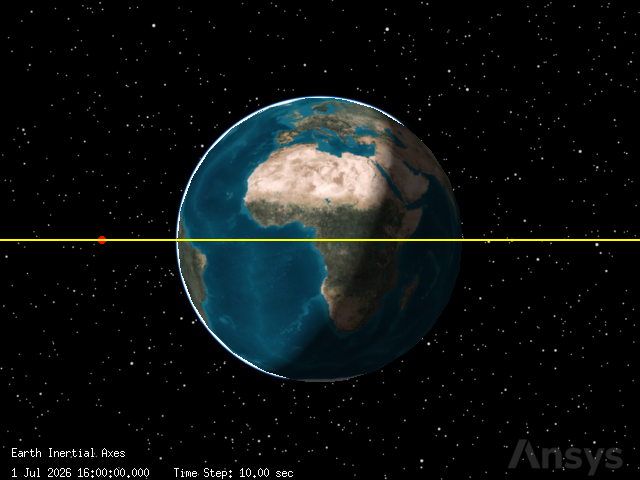

In [72]:
plotter.show()

## Plot the phase angle history

Retrieve and plot the phase angle between the chaser and target satellites over time. To do so, use the scalar calculation AWB component representing the value of the phase angle:

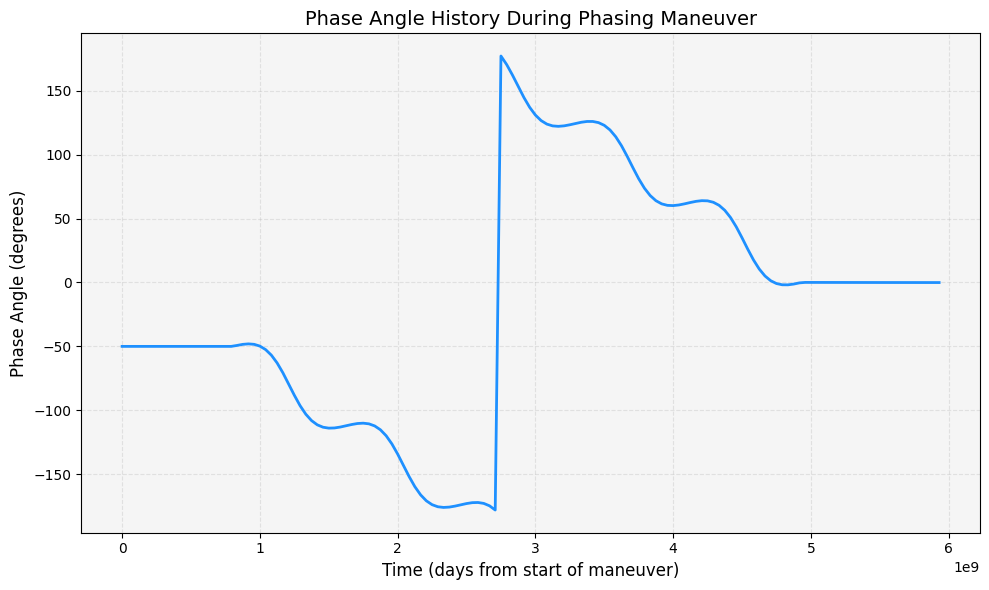

In [73]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


phase_angle_data = scenario.data_providers.item("Scalar Calculations").group.item(
    "Earth PhaseAngle"
)
angle_result = phase_angle_data.execute(scenario.start_time, scenario.stop_time, 3600)
angle_dataframe = angle_result.data_sets.to_pandas_dataframe()
# Convert columns to correct types
angle_dataframe["time"] = pd.to_datetime(angle_dataframe["time"])
angle_dataframe["scalar"] = angle_dataframe["scalar"].apply(pd.to_numeric)

# Get the time values
time = angle_dataframe["time"]

# Convert time to days
start = np.datetime64(datetime.strptime(start_time, "%d %b %Y %H:%M:%S.%f"))
time_days = (time.values - start) / 86400.0

# Get the angle values
phase_angles = angle_dataframe["scalar"]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(time_days, phase_angles, "-", linewidth=2, color="dodgerblue")
plt.xlabel("Time (days from start of maneuver)", fontsize=12)
plt.ylabel("Phase Angle (degrees)", fontsize=12)
plt.title("Phase Angle History During Phasing Maneuver", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Configure style
plt.gca().set_facecolor("whitesmoke")
plt.gca().grid(visible=True, which="both", linestyle="--")

plt.show()

## Plot the orbital altitude history

Retrieve and plot the altitude of both satellites to visualize the phasing orbit:

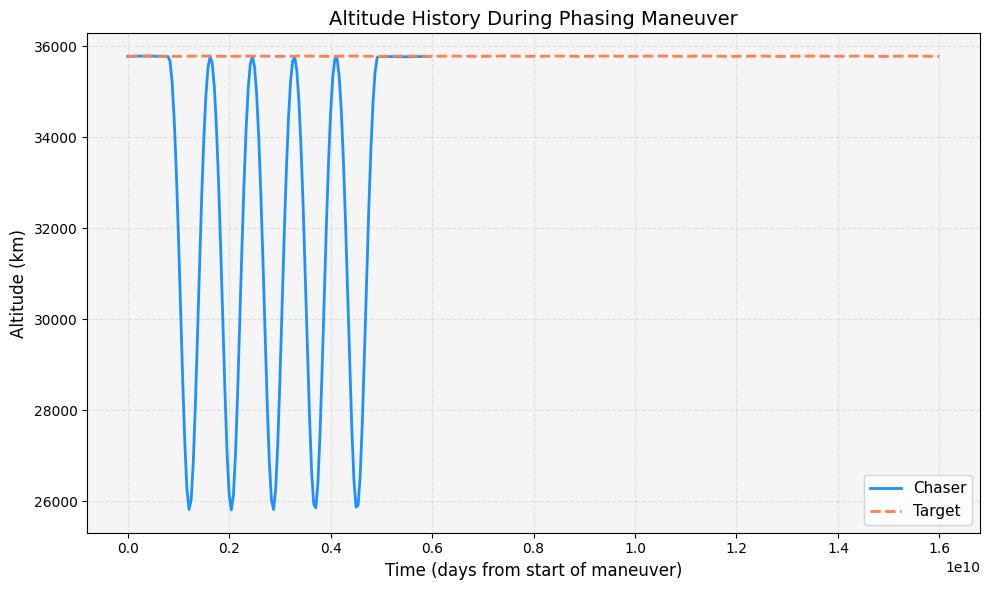

In [74]:
# Get altitude data for chaser satellite
chaser_altitude_provider = chaser_satellite.data_providers["Cartesian Position"].group[
    "Fixed"
]
chaser_altitude_result = chaser_altitude_provider.execute(
    scenario.start_time, scenario.stop_time, 3600
)
chaser_altitude_df = chaser_altitude_result.data_sets.to_pandas_dataframe()

# Calculate magnitude of position vector and subtract Earth radius
earth_radius = 6378.137  # km
chaser_x = chaser_altitude_df["x"].values.astype(float)
chaser_y = chaser_altitude_df["y"].values.astype(float)
chaser_z = chaser_altitude_df["z"].values.astype(float)
chaser_altitude = np.sqrt(chaser_x**2 + chaser_y**2 + chaser_z**2) - earth_radius

# Get altitude data for target satellite
target_altitude_provider = target_satellite.data_providers["Cartesian Position"].group[
    "Fixed"
]
target_altitude_result = target_altitude_provider.execute(
    scenario.start_time, scenario.stop_time, 3600
)
target_altitude_df = target_altitude_result.data_sets.to_pandas_dataframe()

target_x = target_altitude_df["x"].values.astype(float)
target_y = target_altitude_df["y"].values.astype(float)
target_z = target_altitude_df["z"].values.astype(float)
target_altitude = np.sqrt(target_x**2 + target_y**2 + target_z**2) - earth_radius

# Convert time to days
chaser_altitude_df["time"] = pd.to_datetime(chaser_altitude_df["time"])
target_altitude_df["time"] = pd.to_datetime(target_altitude_df["time"])
start = np.datetime64(datetime.strptime(start_time, "%d %b %Y %H:%M:%S.%f"))
chaser_time_days = (chaser_altitude_df["time"].values - start) / 86400.0
target_time_days = (target_altitude_df["time"].values - start) / 86400.0

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(
    chaser_time_days,
    chaser_altitude,
    "-",
    linewidth=2,
    label="Chaser",
    color="dodgerblue",
)
plt.plot(
    target_time_days, target_altitude, "--", linewidth=2, label="Target", color="coral"
)
plt.xlabel("Time (days from start of maneuver)", fontsize=12)
plt.ylabel("Altitude (km)", fontsize=12)
plt.title("Altitude History During Phasing Maneuver", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Configure style
plt.gca().set_facecolor("whitesmoke")
plt.gca().grid(visible=True, which="both", linestyle="--")

plt.show()

## Summary

This example demonstrates how to:

1. Set up two geostationary satellites with different true anomalies
2. Calculate the required phasing orbit parameters using Kepler's equation
3. Design a phasing maneuver sequence with differential corrector profiles
4. Execute the maneuver and retrieve the results
5. Visualize the phase angle and altitude histories

The phasing maneuver successfully brings the chaser satellite to the same orbital position as the target satellite after the specified number of phasing orbits.